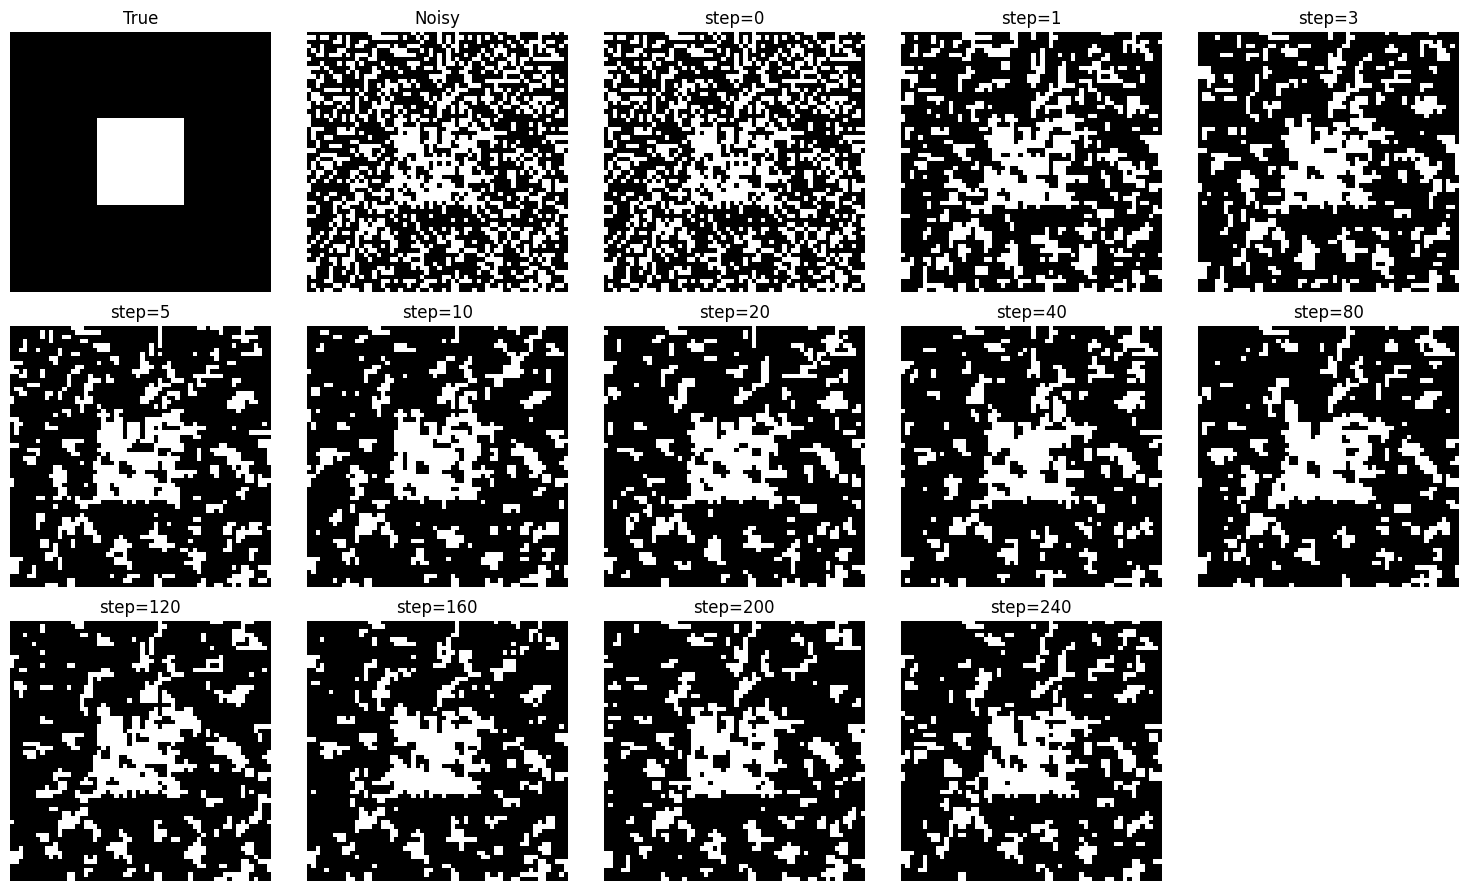

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# =========================
# 設定
# =========================
size = 60
noise_level = 0.35
steps = 240

beta = 0.9
eta  = 2.0

np.random.seed(0)

# =========================
# 元画像（中央に四角）
# =========================
true_img = -np.ones((size, size))

s = size // 3
e = 2 * size // 3
true_img[s:e, s:e] = 1

# =========================
# ノイズ付与
# =========================
observed = true_img.copy()
noise_mask = np.random.rand(size, size) < noise_level
observed[noise_mask] *= -1

# 初期状態
img = observed.copy()

# =========================
# ギブス更新
# =========================
def gibbs_step(img, observed, beta=0.9, eta=2.0):
    h, w = img.shape

    for i in range(h):
        for j in range(w):
            neighbors = (
                img[(i + 1) % h, j] +
                img[(i - 1) % h, j] +
                img[i, (j + 1) % w] +
                img[i, (j - 1) % w]
            )

            field = beta * neighbors + eta * observed[i, j]
            p = 1.0 / (1.0 + np.exp(-2.0 * field))
            img[i, j] = 1 if np.random.rand() < p else -1

    return img

# =========================
# 段階記録
# =========================
checkpoints = [0, 1, 3, 5, 10, 20, 40, 80, 120, 160, 200, 240]
history = []

for t in range(steps + 1):
    if t in checkpoints:
        history.append((t, img.copy()))
    img = gibbs_step(img, observed, beta=beta, eta=eta)

# =========================
# 静止画表示
# True + Noisy + history(12枚) = 14枚必要
# 3x5 = 15枠にする
# =========================
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.ravel()

axes[0].imshow(true_img, cmap="gray")
axes[0].set_title("True")
axes[0].axis("off")

axes[1].imshow(observed, cmap="gray")
axes[1].set_title("Noisy")
axes[1].axis("off")

for i, (t, im) in enumerate(history):
    ax = axes[i + 2]
    ax.imshow(im, cmap="gray")
    ax.set_title(f"step={t}")
    ax.axis("off")

# 余った枠を消す
for j in range(2 + len(history), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()